In [ ]:
#Code
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

#For fixed initialisation
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

LR = 1e-3 # Adam learning rate
WEIGHT_DECAY = 1e-4 # L2 regularisation coefficient
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))   # Fashion-MNIST channel stats (mean and std-dev)
])

train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
val_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

class Fashion(nn.Module):

    def __init__(self):
        super(FashionNet, self).__init__()

        #Shared stem
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        #Branch A  (left path with skip connection)
        self.branch_a1 = nn.Sequential(
            nn.Linear(16, 8),
            nn.BatchNorm1d(8),
            nn.ReLU()
        )
        self.branch_a2 = nn.Sequential(
            nn.Linear(8, 8),
            nn.BatchNorm1d(8),
            nn.ReLU()
        )

        #Branch B  (right path)
        self.branch_b = nn.Sequential(
            nn.Linear(16, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(0.2), #prevents co-adaptation
            nn.Linear(12, 8),
            nn.BatchNorm1d(8),
            nn.ReLU()
        )

        #Output head
        self.output_layer =nn.Linear(16, 10)

        self.initialise_weights()

    def initialise_weights(self):
        """He (Kaiming) initialisation for all Linear layers; zeros for biases."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Shared stem
        shared_out = self.shared(x)

        # Branch A with skip connection
        a1 = self.branch_a1(shared_out)
        a2 = self.branch_a2(a1)
        skip_out = a1 + a2

        # Branch B
        b_out = self.branch_b(shared_out)

        # Concatenate
        concat = torch.cat([skip_out, b_out], dim=1)

        # Output
        logits = self.output_layer(concat)
        return logits

#Training
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model.forward(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total * 100.0

#Evaluation(No gradient calculation)
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate on a data-loader; return avg loss & accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model.forward(images)
        loss   = criterion(logits, labels) #mean batch loss

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total * 100.0


model     = Fashion().to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

best_val_acc = 0.0

for epoch in range(1, 51):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    if epoch%5==0 or epoch==1:
        print(f"Epoch: {epoch} | Training Loss: {train_loss} | Training Accuracy: {train_acc}% | Validation Loss: {val_loss} | Validation Accuracy: {val_acc}%")

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {}
        for k, v in model.state_dict().items():
            best_state[k] = v.cpu().clone()
print("\n")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

#Save model weights
weights_path = "model_weights.pkl"
with open(weights_path, "wb") as f:
    pickle.dump(best_state, f)
print(f"Best model weights saved: {weights_path}")

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

#Training curves
epochs_range = range(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fashion-MNIST Training History", fontsize=14, fontweight="bold")

# Loss plot
axes[0].plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "r-s", markersize=4, label="Val Loss")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Accuracy plot
axes[1].plot(epochs_range, history["train_acc"], "b-o", markersize=4, label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "r-s", markersize=4, label="Val Acc")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved successfully: training_curves.png")

#Submission.csv
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

model.eval()
predsarray, ids = [], []
sample_id = 0

with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(DEVICE)
        logits = model(images)
        preds  = logits.argmax(dim=1).cpu()
        for p in preds:
            ids.append(sample_id)
            predsarray.append(p.item())
            sample_id += 1

submission = pd.DataFrame({
    "id":    ids,
    "label": predsarray,
    "class": [CLASS_NAMES[p] for p in predsarray]
})
submission.to_csv("submission.csv", index=False)
print("Submission file created successfully: submission.csv")

#Final evaluation on validation set
val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
print(f"Validation Loss: {val_loss}  |  Validation Accuracy: {val_acc}%")

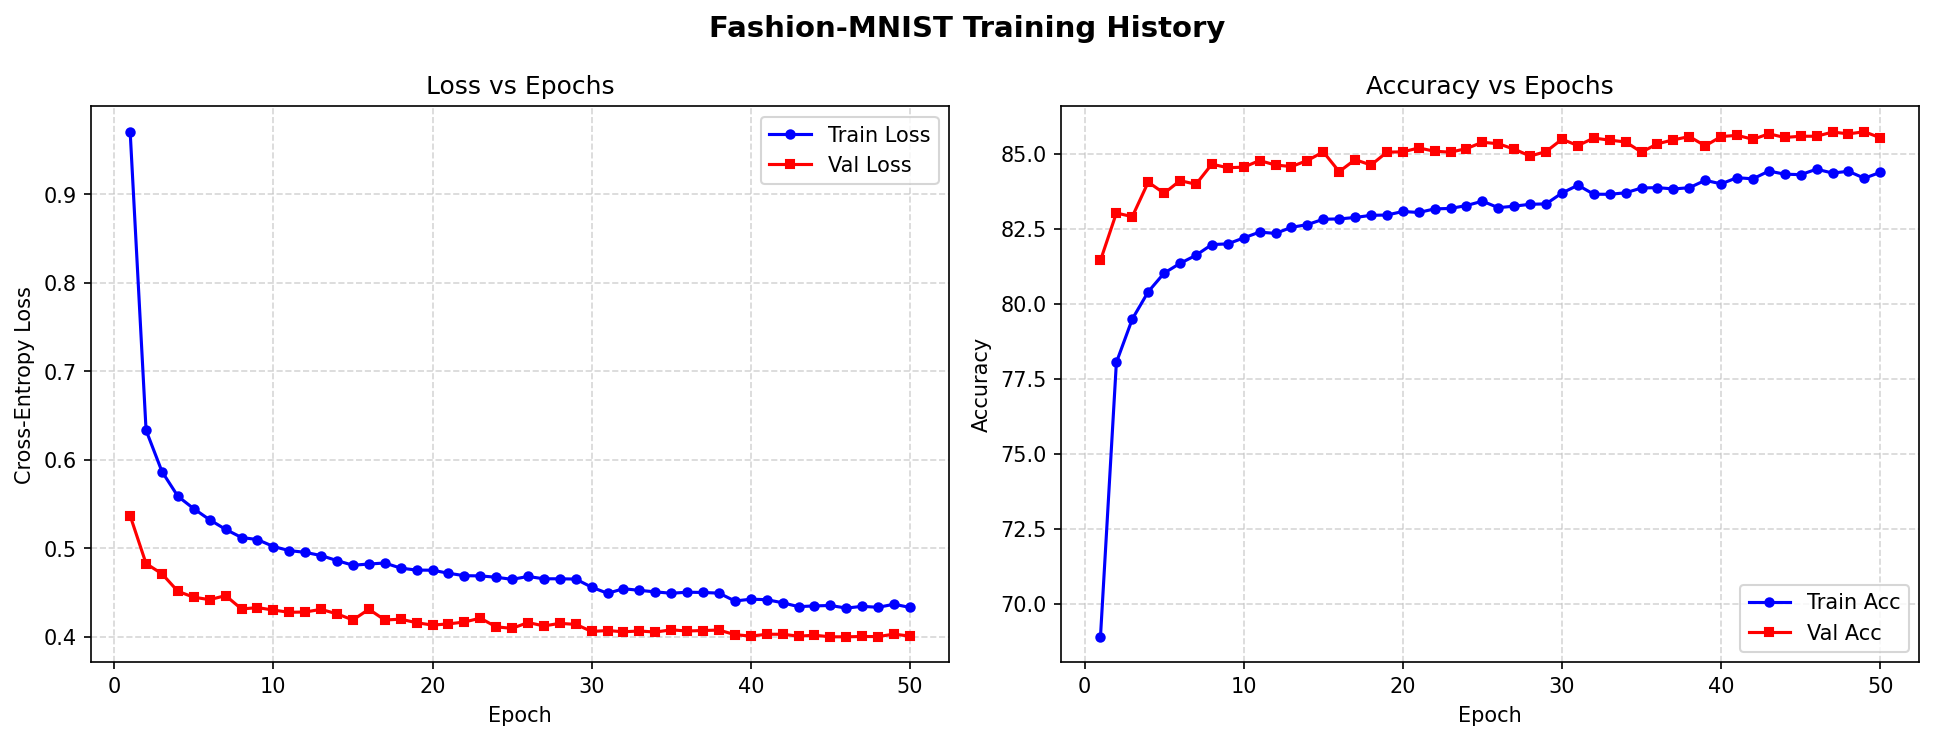

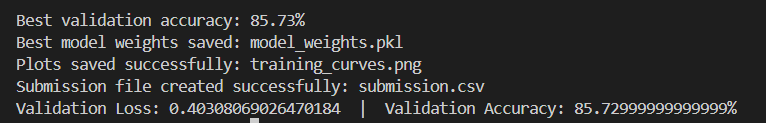